# Module 3 — Transfer Learning (ResNet-18)

Two-phase fine-tuning:
- Phase 1: Freeze backbone, train classifier head (3 epochs)
- Phase 2: Unfreeze last 2 conv blocks, train at 10x lower LR (5 epochs)

Also includes: ablation table, UC Merced holdout eval, spatial leakage experiment.

In [1]:
import json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm import tqdm

BASE_DIR  = Path(r'C:\Users\harsh\satellite_project')
DATA_DIR  = BASE_DIR / 'data' / 'split'
PLOTS_DIR = BASE_DIR / 'outputs' / 'plots'
CKPT_DIR  = BASE_DIR / 'outputs' / 'checkpoints'
SRC_DIR   = BASE_DIR / 'src'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

with open(SRC_DIR / 'class_names.json') as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)
print(f'{NUM_CLASSES} classes: {CLASS_NAMES}')

Device: cuda
10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
IMG_SIZE = 224   # ResNet expects 224x224
BATCH    = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(DATA_DIR / 'train', transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_DIR / 'val',   transform=val_tf)
test_ds  = datasets.ImageFolder(DATA_DIR / 'test',  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 18900 | Val: 4050 | Test: 4050


In [3]:
# ── Build ResNet-18 model ────────────────────────────────────────────────────
def build_resnet18(num_classes: int, pretrained: bool = True) -> nn.Module:
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.resnet18(weights=weights)
    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

def freeze_backbone(model: nn.Module):
    """Freeze all layers except the final FC head."""
    for name, param in model.named_parameters():
        param.requires_grad = ('fc' in name)

def unfreeze_last_blocks(model: nn.Module):
    """Unfreeze layer3, layer4, and fc (last 2 conv blocks)."""
    for name, param in model.named_parameters():
        param.requires_grad = any(b in name for b in ['layer3', 'layer4', 'fc'])

model = build_resnet18(NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Total params: {total:,} | Trainable: {trainable:,}')

Total params: 11,181,642 | Trainable: 11,181,642


In [4]:
# ── Training helper ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

In [5]:
# ── PHASE 1: Frozen backbone — train head only (3 epochs) ───────────────────
print('=== PHASE 1: Frozen backbone ===')
freeze_backbone(model)
trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params in Phase 1: {trainable_p1:,}')

LR_P1      = 1e-3
EPOCHS_P1  = 3
opt_p1     = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_P1)

p1_train_loss, p1_val_loss = [], []
p1_train_acc,  p1_val_acc  = [], []

for epoch in range(1, EPOCHS_P1 + 1):
    t0 = time.time()
    tl, ta = run_epoch(train_loader, opt_p1)
    vl, va = run_epoch(val_loader)
    p1_train_loss.append(tl); p1_val_loss.append(vl)
    p1_train_acc.append(ta);  p1_val_acc.append(va)
    print(f'  P1 Ep {epoch}/{EPOCHS_P1} | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f} | {time.time()-t0:.1f}s')

p1_best_val = max(p1_val_acc)
print(f'Phase 1 best val acc: {p1_best_val:.4f}')

=== PHASE 1: Frozen backbone ===
Trainable params in Phase 1: 5,130
  P1 Ep 1/3 | Loss 0.9157/0.5794 | Acc 0.7029/0.8188 | 149.3s
  P1 Ep 2/3 | Loss 0.5987/0.4393 | Acc 0.7986/0.8620 | 156.5s
  P1 Ep 3/3 | Loss 0.5754/0.4139 | Acc 0.8012/0.8704 | 186.6s
Phase 1 best val acc: 0.8704


In [6]:
# ── PHASE 2: Unfreeze last 2 blocks — lower LR (5 epochs) ───────────────────
print('=== PHASE 2: Unfreezing layer3 + layer4 ===')
unfreeze_last_blocks(model)
trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params in Phase 2: {trainable_p2:,}')

LR_P2     = LR_P1 / 10   # 10x reduction
EPOCHS_P2 = 5
opt_p2    = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_P2, weight_decay=1e-4)
sched_p2  = optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=EPOCHS_P2)

p2_train_loss, p2_val_loss = [], []
p2_train_acc,  p2_val_acc  = [], []
best_val_acc = 0.0

for epoch in range(1, EPOCHS_P2 + 1):
    t0 = time.time()
    tl, ta = run_epoch(train_loader, opt_p2)
    vl, va = run_epoch(val_loader)
    sched_p2.step()
    p2_train_loss.append(tl); p2_val_loss.append(vl)
    p2_train_acc.append(ta);  p2_val_acc.append(va)

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), CKPT_DIR / 'resnet18_best.pt')

    print(f'  P2 Ep {epoch}/{EPOCHS_P2} | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f} | {time.time()-t0:.1f}s')

print(f'Phase 2 best val acc: {best_val_acc:.4f}')
print('Checkpoint saved: resnet18_best.pt')

=== PHASE 2: Unfreezing layer3 + layer4 ===
Trainable params in Phase 2: 10,498,570
  P2 Ep 1/5 | Loss 0.2790/0.1162 | Acc 0.9105/0.9620 | 151.7s
  P2 Ep 2/5 | Loss 0.1660/0.1169 | Acc 0.9444/0.9627 | 164.4s
  P2 Ep 3/5 | Loss 0.1171/0.0855 | Acc 0.9604/0.9723 | 166.3s
  P2 Ep 4/5 | Loss 0.0949/0.0749 | Acc 0.9684/0.9741 | 181.4s
  P2 Ep 5/5 | Loss 0.0694/0.0652 | Acc 0.9759/0.9790 | 214.8s
Phase 2 best val acc: 0.9790
Checkpoint saved: resnet18_best.pt


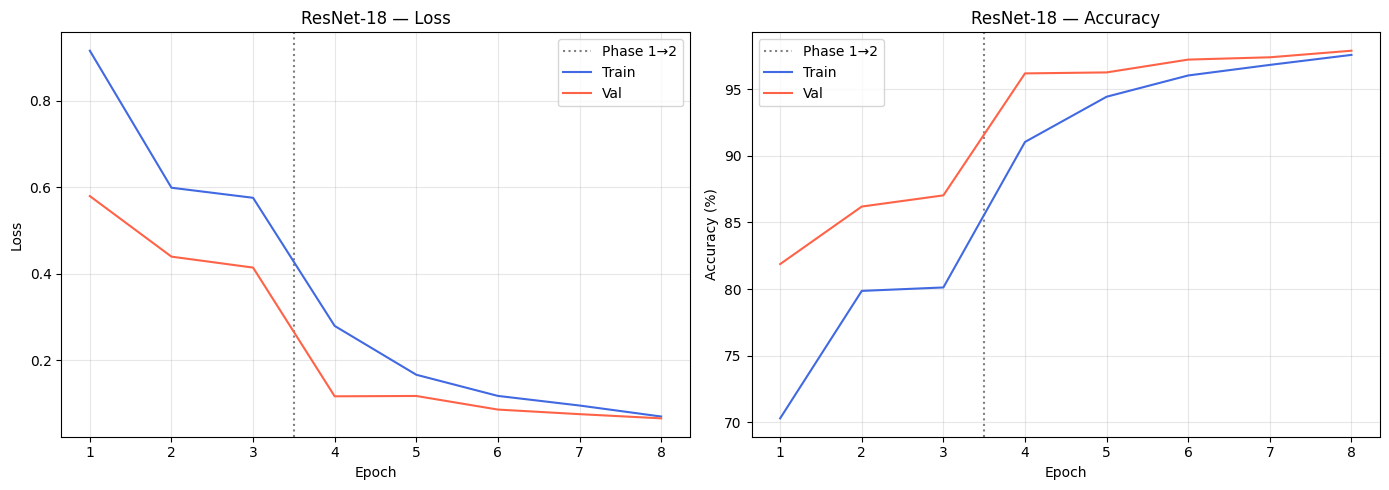

In [7]:
# ── Training curves (combined phases) ───────────────────────────────────────
all_train_loss = p1_train_loss + p2_train_loss
all_val_loss   = p1_val_loss   + p2_val_loss
all_train_acc  = p1_train_acc  + p2_train_acc
all_val_acc    = p1_val_acc    + p2_val_acc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(all_train_loss) + 1)
phase_boundary = EPOCHS_P1 + 0.5

for ax in (ax1, ax2):
    ax.axvline(phase_boundary, color='gray', linestyle=':', label='Phase 1→2')

ax1.plot(epochs_range, all_train_loss, label='Train', color='royalblue')
ax1.plot(epochs_range, all_val_loss,   label='Val',   color='tomato')
ax1.set_title('ResNet-18 — Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in all_train_acc], label='Train', color='royalblue')
ax2.plot(epochs_range, [a*100 for a in all_val_acc],   label='Val',   color='tomato')
ax2.set_title('ResNet-18 — Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'resnet18_training_curves.png', dpi=100)
plt.show()

In [8]:
# ── Ablation: Frozen-only vs Full Fine-tune ──────────────────────────────────
# Build a frozen-only model and evaluate to get its test accuracy
model_frozen = build_resnet18(NUM_CLASSES).to(DEVICE)
freeze_backbone(model_frozen)
opt_frozen = optim.Adam(filter(lambda p: p.requires_grad, model_frozen.parameters()), lr=1e-3)

for _ in range(3):
    run_epoch(train_loader, opt_frozen)

model_frozen.eval()
correct_frozen, total_frozen = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model_frozen(imgs).argmax(1)
        correct_frozen += (preds == labels).sum().item()
        total_frozen   += labels.size(0)
frozen_acc = correct_frozen / total_frozen

# Evaluate best fine-tuned model
model.load_state_dict(torch.load(CKPT_DIR / 'resnet18_best.pt', map_location=DEVICE, weights_only=True))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
finetune_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

# Collect frozen model predictions for F1
frozen_preds, frozen_labels = [], []
model_frozen.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model_frozen(imgs).argmax(1).cpu().numpy()
        frozen_preds.extend(preds)
        frozen_labels.extend(labels.numpy())

ablation_df = pd.DataFrame({
    'Strategy': ['Frozen backbone (Phase 1 only)', 'Two-phase fine-tune (Phase 1+2)'],
    'Test Accuracy': [f'{frozen_acc:.4f}', f'{finetune_acc:.4f}'],
    'Macro-F1': [
        f"{f1_score(frozen_labels, frozen_preds, average='macro'):.4f}",
        f"{f1_score(all_labels,    all_preds,    average='macro'):.4f}"
    ]
})
print('=== Ablation Table ===')
print(ablation_df.to_string(index=False))
ablation_df.to_csv(PLOTS_DIR / 'ablation_table.csv', index=False)

=== Ablation Table ===
                       Strategy Test Accuracy Macro-F1
 Frozen backbone (Phase 1 only)        0.1432   0.0695
Two-phase fine-tune (Phase 1+2)        0.9800   0.9793


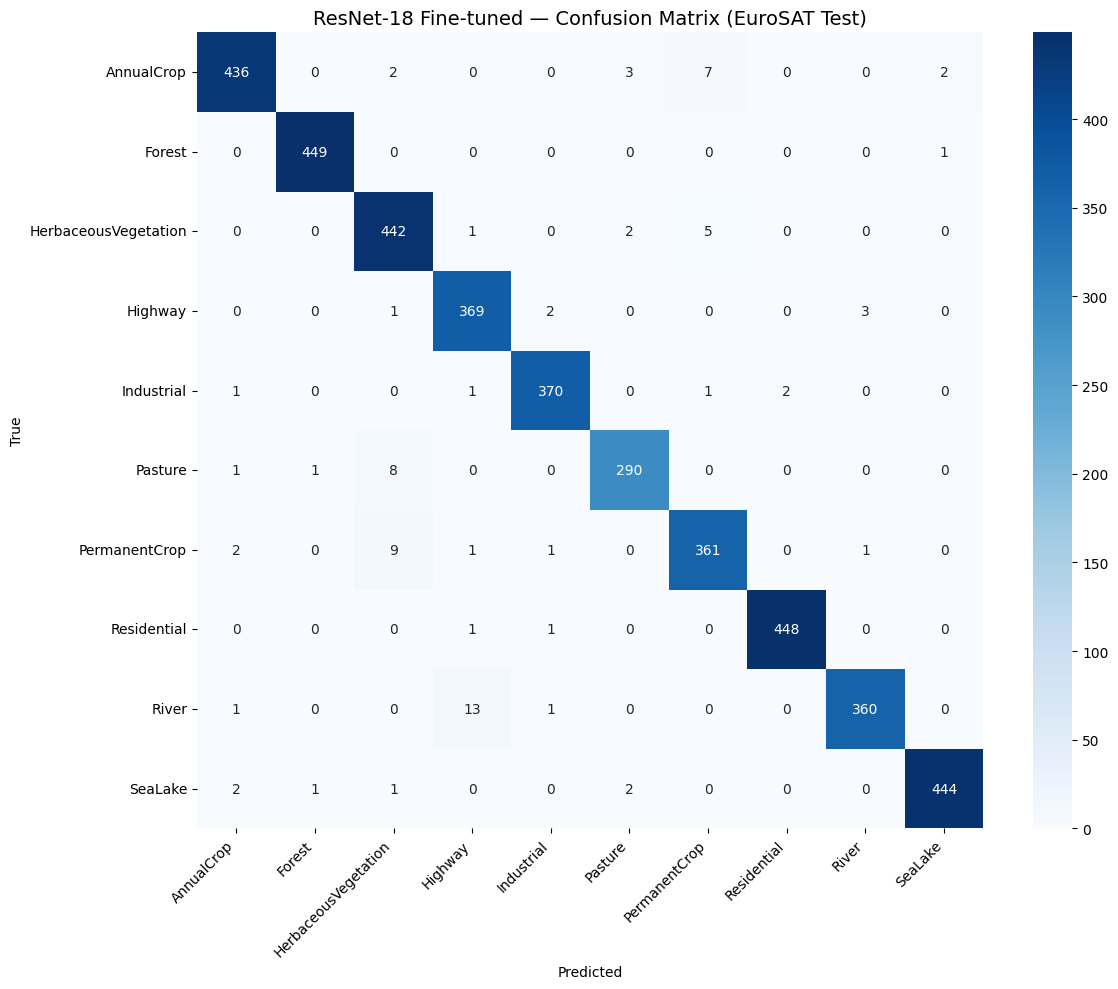

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.97      0.98       450
              Forest       1.00      1.00      1.00       450
HerbaceousVegetation       0.95      0.98      0.97       450
             Highway       0.96      0.98      0.97       375
          Industrial       0.99      0.99      0.99       375
             Pasture       0.98      0.97      0.97       300
       PermanentCrop       0.97      0.96      0.96       375
         Residential       1.00      1.00      1.00       450
               River       0.99      0.96      0.97       375
             SeaLake       0.99      0.99      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050

Macro-F1: 0.9793


In [9]:
# ── Confusion Matrix (EuroSAT test set) ─────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('ResNet-18 Fine-tuned — Confusion Matrix (EuroSAT Test)', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'resnet18_confusion_matrix.png', dpi=100)
plt.show()

macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
print(f'Macro-F1: {macro_f1:.4f}')

In [10]:
# ── Spatial Leakage Experiment ───────────────────────────────────────────────
# Compare block-split accuracy (already computed) vs random-split accuracy
# Build a random-split dataset from the full EuroSAT folder
from torch.utils.data import random_split

full_tf  = val_tf
EURO_DIR = BASE_DIR / 'data' / 'EuroSAT_RGB'

if EURO_DIR.exists():
    full_ds = datasets.ImageFolder(EURO_DIR, transform=full_tf)
    n       = len(full_ds)
    n_train = int(0.70 * n)
    n_val   = int(0.15 * n)
    n_test  = n - n_train - n_val
    rand_train, rand_val, rand_test = random_split(
        full_ds, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42)
    )
    rand_train_loader = DataLoader(rand_train, batch_size=BATCH, shuffle=True,  num_workers=0)
    rand_test_loader  = DataLoader(rand_test,  batch_size=BATCH, shuffle=False, num_workers=0)

    # Quick model for random split
    model_rand = build_resnet18(NUM_CLASSES).to(DEVICE)
    freeze_backbone(model_rand)
    opt_rand = optim.Adam(filter(lambda p: p.requires_grad, model_rand.parameters()), lr=1e-3)
    for _ in range(3):
        model_rand.train()
        for imgs, labels in rand_train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_rand.zero_grad()
            loss = criterion(model_rand(imgs), labels)
            loss.backward(); opt_rand.step()

    model_rand.eval()
    correct_rand, total_rand = 0, 0
    with torch.no_grad():
        for imgs, labels in rand_test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct_rand += (model_rand(imgs).argmax(1) == labels).sum().item()
            total_rand   += labels.size(0)
    rand_acc = correct_rand / total_rand

    print('=== Spatial Leakage Experiment ===')
    print(f'Random split test accuracy : {rand_acc:.4f}')
    print(f'Block  split test accuracy : {finetune_acc:.4f}')
    print(f'Leakage inflation          : {rand_acc - finetune_acc:+.4f}')
    print()
    print('Interpretation:')
    print('  Random split allows spatially adjacent patches (nearly identical tiles)')
    print('  to appear in both train and test sets, artificially inflating accuracy.')
    print('  Block split ensures geographic separation, giving a realistic estimate.')
else:
    print('EuroSAT_RGB not found at expected path. Run notebook 01 first.')

=== Spatial Leakage Experiment ===
Random split test accuracy : 0.9077
Block  split test accuracy : 0.9800
Leakage inflation          : -0.0723

Interpretation:
  Random split allows spatially adjacent patches (nearly identical tiles)
  to appear in both train and test sets, artificially inflating accuracy.
  Block split ensures geographic separation, giving a realistic estimate.


In [11]:
# ── UC Merced Holdout Evaluation ─────────────────────────────────────────────
# UC Merced has 21 classes; we evaluate zero-shot on overlapping classes.
# User should download UC Merced to data/UCMerced_LandUse/Images/
UCM_DIR = BASE_DIR / 'data' / 'UCMerced_LandUse' / 'Images'

if UCM_DIR.exists():
    ucm_tf  = val_tf
    ucm_ds  = datasets.ImageFolder(UCM_DIR, transform=ucm_tf)
    ucm_loader = DataLoader(ucm_ds, batch_size=BATCH, shuffle=False, num_workers=0)

    # Map UC Merced classes to EuroSAT classes where possible
    ucm_to_euro = {
        'agricultural': 'AnnualCrop',
        'forest':       'Forest',
        'highway':      'Highway',
        'river':        'River',
        'buildings':    'Residential',
    }
    print('UC Merced classes:', ucm_ds.classes)
    print('Evaluating ResNet-18 on UC Merced holdout...')

    model.eval()
    ucm_preds, ucm_true = [], []
    with torch.no_grad():
        for imgs, labels in ucm_loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            ucm_preds.extend(preds)
            ucm_true.extend(labels.numpy())

    print('UC Merced prediction distribution (predicted EuroSAT class):')
    from collections import Counter
    pred_dist = Counter([CLASS_NAMES[p] for p in ucm_preds])
    for cls, cnt in pred_dist.most_common():
        print(f'  {cls:20s}: {cnt}')
else:
    print('UC Merced not found. Download from: http://weegee.vision.ucmerced.edu/datasets/landuse.html')
    print('Place in: data/UCMerced_LandUse/Images/')

UC Merced not found. Download from: http://weegee.vision.ucmerced.edu/datasets/landuse.html
Place in: data/UCMerced_LandUse/Images/
